
# QRC SWAPTION MODEL
# Photonic Echo-State + Proper Lyapunov Regularisation

 **Quantum Reservoir Computing (QRC)** model for swaption volatility surface prediction.

**Architecture overview:**
- True photonic Fock simulation via Merlin
- 8 modes, 4 photons
- Leaky Quantum Echo-State architecture
- Proper Lyapunov-based adaptive λ regularisation
- Ridge readout layer

**Dataset:** `Quandela/Challenge_Swaptions` — Level 2 Missing Data Prediction

In [ ]:
!pip install datasets
!pip install torch
!pip install merlinquantum
!pip install perceval-quandela


##  Step 1 — Imports

In [ ]:
import warnings
import numpy as np
import pandas as pd
import torch
import merlin
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from datasets import load_dataset
from merlin import QuantumLayer, MeasurementStrategy, ComputationSpace
from scipy.linalg import qr
import perceval as pcvl

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Merlin version:", merlin.__version__)

Device: cpu
Merlin version: 0.2.3


##  2 — Load Challenge Dataset (Level 2)

We load the Level-2 Missing Data Prediction training CSV from the Quandela Challenge Swaptions dataset.
Date columns are dropped, and any missing values are forward-filled then zero-filled.

In [ ]:
print("Loading Quandela Challenge Swaption dataset...")

ds = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-2_Missing_data_prediction/train_level2.csv",
    split="train",
)

df = ds.to_pandas()

date_col = [c for c in df.columns if "date" in c.lower()]
if date_col:
    df = df.drop(columns=date_col)

df = df.select_dtypes(include=np.number).fillna(method="ffill").fillna(0)

print("Surface shape:", df.shape)
df.head()

Loading Quandela Challenge Swaption dataset...


README.md: 0.00B [00:00, ?B/s]

train_level2.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Surface shape: (489, 224)


,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,0.028565,0.038700,0.040127,0.040762,0.040466,0.038953,0.037553,0.036768,0.036646,0.035595,...,0.331053,0.329056,0.330997,0.324676,0.325758,0.322393,0.345859,0.359162,0.346670,0.337670
1,0.029334,0.039499,0.040982,0.041638,0.041336,0.039815,0.038397,0.037631,0.037504,0.036437,...,0.336319,0.334434,0.336568,0.330244,0.331462,0.328144,0.351816,0.365197,0.350993,0.340822
2,0.028696,0.038816,0.040328,0.041042,0.040804,0.039329,0.037968,0.037216,0.037107,0.036062,...,0.333634,0.331707,0.333800,0.327487,0.328710,0.325436,0.348915,0.362236,0.348652,0.339027
3,0.030854,0.041536,0.043035,0.043605,0.043241,0.041556,0.039977,0.039167,0.038968,0.037793,...,0.336884,0.335106,0.337548,0.331279,0.332811,0.329771,0.353246,0.366100,0.351404,0.340465
4,0.030406,0.041174,0.042681,0.043266,0.042937,0.041253,0.039685,0.038867,0.038667,0.037492,...,0.333249,0.331426,0.333830,0.327580,0.329123,0.326146,0.349390,0.362048,0.348331,0.338022


## Step 3 — Parse Tenor / Maturity Grid

Extract the tenor and maturity dimensions from column names so we can reshape flat surfaces into proper 2D grids for visualisation.

In [ ]:
surface_cols = list(df.columns)

tenors = []
maturities = []

for col in surface_cols:
    t_match = re.search(r"Tenor\s*[:\-]\s*([\d.]+)", col)
    m_match = re.search(r"Maturit\w*\s*[:\-]\s*([\d.]+)", col)
    if t_match and m_match:
        tenors.append(float(t_match.group(1)))
        maturities.append(float(m_match.group(1)))
    else:
        tenors.append(0.0)
        maturities.append(0.0)

tenors = np.array(tenors)
maturities = np.array(maturities)

unique_tenors     = np.sort(np.unique(tenors))
unique_maturities = np.sort(np.unique(maturities))

n_t = len(unique_tenors)
n_m = len(unique_maturities)

print("Grid size:", n_t, "x", n_m)
print("Tenors:",     unique_tenors)
print("Maturities:", unique_maturities)


def reshape_surface(flat_surface):
    """Reshape a flat vol surface vector into a (n_tenor x n_maturity) grid."""
    surface_grid = np.zeros((n_t, n_m))
    for i, (t, m) in enumerate(zip(tenors, maturities)):
        t_idx = np.where(unique_tenors == t)[0][0]
        m_idx = np.where(unique_maturities == m)[0][0]
        surface_grid[t_idx, m_idx] = flat_surface[i]
    return surface_grid

Grid size: 14 x 16
Tenors: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 15. 20. 25. 30.]
Maturities: [ 0.08333333  0.25        0.5         0.75        1.          1.5
  2.          3.          4.          5.          7.         10.
 15.         20.         25.         30.        ]


## Step 4 — Hyperparameters

All model hyperparameters defined in one place for easy tuning.

In [ ]:
N_MODES            = 8
N_PHOTONS          = 4
N_ENCODING_BLOCKS  = 4
CIRCUIT_INPUT_DIM  = N_MODES * N_ENCODING_BLOCKS
N_PCA              = 16
MEMORY_R           = CIRCUIT_INPUT_DIM - N_PCA
LEAKY_EPS          = 0.6
LAMBDA_BASE        = 1e-4
TEST_FRAC          = 0.2
WARMUP             = 20

print(f"Modes: {N_MODES}, Photons: {N_PHOTONS}")
print(f"PCA components: {N_PCA}")
print(f"Circuit input dim: {CIRCUIT_INPUT_DIM}  (PCA={N_PCA} + Memory={MEMORY_R})")
print(f"Leaky rate ε: {LEAKY_EPS}, Base λ: {LAMBDA_BASE}")
print(f"Warmup steps: {WARMUP}, Test fraction: {TEST_FRAC}")

Modes: 8, Photons: 4
PCA components: 16
Circuit input dim: 32  (PCA=16 + Memory=16)
Leaky rate ε: 0.6, Base λ: 0.0001
Warmup steps: 20, Test fraction: 0.2


## Step 5 — Preprocessing: Scaling + PCA

1. `MinMaxScaler` normalises each vol surface column to [0, 1].
2. `PCA` compresses 224-dim surfaces to `N_PCA` principal components.
3. We form the one-step-ahead increments `ΔX_t = X_{t+1} - X_t` as prediction targets.

In [ ]:
scaler = MinMaxScaler()
pca    = PCA(n_components=N_PCA)

scaled  = scaler.fit_transform(df.values.astype(np.float32))
factors = pca.fit_transform(scaled)

print("Factor shape:", factors.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o', linewidth=2)
plt.axhline(99.0, color='red', linestyle='--', label='99% threshold')
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Explained Variance — Level 2 Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 6 — Train / Test Split

We use an 80/20 temporal split (no shuffling — time-series data).
- `X` = current PCA factors
- `dY` = one-step-ahead increments (prediction target)

In [ ]:
X  = factors[:-1]        # X_t
Y  = factors[1:]         # X_{t+1}
dY = Y - X               # ΔX_t  (prediction target)

T     = len(X)
split = int(T * (1 - TEST_FRAC))

X_train, X_test = X[:split],  X[split:]
Y_train, Y_test = dY[:split], dY[split:]

print(f"Total timesteps : {T}")
print(f"Train size      : {len(X_train)}  (after warmup effective: {len(X_train) - WARMUP})")
print(f"Test  size      : {len(X_test)}")

# Visualise PCA factors over time
plt.figure(figsize=(14, 5))
for i in range(min(5, N_PCA)):
    plt.plot(factors[:, i], label=f"PC{i}")
plt.axvline(split, color='black', linestyle='--', label='Train/Test split')
plt.title("PCA Components Over Time")
plt.xlabel("Time Index")
plt.ylabel("PCA Coefficient")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##  Step 7 — Photonic Quantum Reservoir Architecture

We define the full `PhotonicQuantumReservoirNetwork` class (architecture unchanged).

**Key components:**
- **CircuitBuilder**: Constructs the photonic interferometer (angle encoding → superpositions → fixed entangling layer → angle encoding)
- **QuantumLayer**: Merlin layer computing Fock-space probabilities — the reservoir state
- **Leaky integration**: `z(t) = (1−ε)·z(t−1) + ε·Φ(u_t)`
- **Ridge readout**: closed-form `W = (Z^T Z + λI)^{-1} Z^T Y`
- **Lyapunov Jacobian**: Stability analysis via parameter-shift rule

# {Lyapunov-Adaptive Regularization in Photonic Reservoir Computing}

Consider the leaky quantum reservoir defined by

$$\begin{equation}
z_{t} = (1-\epsilon) z_{t-1} + \epsilon \Phi(u_t),
\end{equation}

where $z_t \in \mathbb{R}^{d}$ denotes the reservoir state and
$\Phi(\cdot)$ represents the nonlinear photonic mapping induced by the
measurement probabilities of the interferometric circuit.

In closed-loop mode, the system defines a discrete-time dynamical map

\begin{equation}
z_{t+1} = F(z_t).
\end{equation}

{Lyapunov Stability Considerations}

The maximal Lyapunov exponent for a discrete system is defined as

\begin{equation}
\lambda_{\max} =
\lim_{T \to \infty}
\frac{1}{T}
\sum_{t=0}^{T-1}
\log \left\| DF(z_t) v_t \right\|,
\end{equation}

where $DF(z_t)$ is the Jacobian of the map and $v_t$
is an evolving tangent vector.

A positive $\lambda_{\max}$ indicates exponential divergence
of nearby trajectories (chaotic regime),
while a negative value indicates contraction and stability.

{Empirical Lyapunov Proxy}

Direct computation of $DF(z_t)$ is expensive.
Instead, we define the finite-difference variation

\begin{equation}
\Delta z_t = z_{t+1} - z_t.
\end{equation}

Stacking these into a matrix

\begin{equation}
D =
\begin{bmatrix}
\Delta z_1 \\
\Delta z_2 \\
\vdots
\end{bmatrix},
\end{equation}

we estimate dynamical expansion by the largest singular value

\begin{equation}
\sigma_{\max}(D).
\end{equation}

This quantity serves as a proxy for the dominant amplification direction
of the reservoir dynamics.

{Adaptive Ridge Regularization}

The readout weights are obtained by ridge regression

\begin{equation}
W =
(Z^\top Z + \lambda I)^{-1} Z^\top Y.
\end{equation}

To mitigate instability amplification,
we adapt the regularization parameter as

\begin{equation}
\lambda_{\text{adaptive}} =
\lambda_0 \max(1, \sigma_{\max}(D)).
\end{equation}

Thus, when the reservoir exhibits strong dynamical expansion,
additional regularization is imposed to suppress overfitting
along unstable directions.

This mechanism effectively couples dynamical stability
with statistical generalization.

In [ ]:
class PhotonicQuantumReservoirNetwork:
    def __init__(self, n_modes, n_photons, epsilon_q, tikh_q, dim, config):
        self.n_modes    = n_modes
        self.n_photons  = n_photons
        self.epsilon_q  = epsilon_q  # Leaking rate
        self.tikh_q     = np.atleast_1d(tikh_q)
        self.dim        = dim        # Input/Output dimension (e.g., PCA factors)
        self.config     = config

        self.qlayer   = self._build_photonic_circuit()
        self.N_units  = self.qlayer.output_size

        self.bias_out = np.array([1.0])
        self.Wout_q   = None

    def _build_photonic_circuit(self):
        """Constructs the photonic reservoir using Merlin's CircuitBuilder."""
        builder = merlin.CircuitBuilder(n_modes=self.n_modes)

        if self.config == 1:
            builder.add_superpositions(depth=1)
            builder.add_angle_encoding()
            builder.add_entangling_layer(trainable=True)
            builder.add_angle_encoding()
        else:
            builder.add_angle_encoding()
            builder.add_superpositions(depth=1)
            builder.add_entangling_layer(trainable=True)
            builder.add_angle_encoding()

        qlayer = QuantumLayer(
            input_size=self.dim,
            builder=builder,
            n_photons=self.n_photons,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.FOCK
            )
        )

        for p in qlayer.parameters():
            p.requires_grad_(True)

        return qlayer

    @torch.no_grad()
    def quantum_step(self, prob_p, x_in):
        """Advances the reservoir by one time step."""
        u_t    = torch.tensor(x_in, dtype=torch.float32).view(1, -1)
        phi_z  = self.qlayer(u_t).squeeze(0).numpy()
        prob_new = (1 - self.epsilon_q) * prob_p + self.epsilon_q * phi_z
        return np.hstack([prob_new, self.bias_out])

    def quantum_training(self, U_washout, U_train, Y_train):
        """Standard Ridge Regression Training for QRC."""
        x_state = np.zeros(self.N_units)
        for u in U_washout:
            res     = self.quantum_step(x_state, u)
            x_state = res[:self.N_units]

        states = []
        for u in U_train:
            res     = self.quantum_step(x_state, u)
            states.append(res)
            x_state = res[:self.N_units]

        Xa  = np.array(states)
        LHS = Xa.T @ Xa
        RHS = Xa.T @ Y_train

        Wout_list = []
        for lamb in self.tikh_q:
            W = np.linalg.solve(LHS + lamb * np.eye(LHS.shape[0]), RHS)
            Wout_list.append(W)

        self.Wout_q = np.array(Wout_list)
        return Xa, self.Wout_q

    def quantum_closed_loop_jacobian(self, N, x0, Wout, dt):
        """Calculates Lyapunov Exponents using the Photonic Jacobian."""
        N_test = N - int(N / 10)
        LE     = np.zeros((N_test, self.dim))

        x_state = x0[:self.N_units]
        U_orth  = qr(np.random.rand(self.N_units, self.dim))[0][:, :self.dim]

        for i in range(N):
            y_pred  = np.dot(np.hstack([x_state, self.bias_out]), Wout)
            grad_y  = self._calculate_photonic_gradient(y_pred)
            jacobian = (1 - self.epsilon_q) * np.eye(self.N_units) + \
                       self.epsilon_q * (grad_y @ Wout[:self.N_units, :].T)
            U_orth   = jacobian @ U_orth

            if i % 1 == 0:
                Q, R   = qr(U_orth)
                U_orth = Q[:, :self.dim]
                if i >= (N - N_test):
                    LE[i - (N - N_test)] = np.log(np.abs(np.diag(R)))

            res     = self.quantum_step(x_state, y_pred)
            x_state = res[:self.N_units]

        return LE.mean(axis=0) / dt

    def _calculate_photonic_gradient(self, y_val):
        """Approximates the gradient of the photonic circuit w.r.t input angles."""
        shift = np.pi / 2
        grad  = np.zeros((self.N_units, self.dim))

        for d in range(self.dim):
            y_plus  = y_val.copy(); y_plus[d]  += shift
            y_minus = y_val.copy(); y_minus[d] -= shift

            phi_plus  = self.qlayer(torch.tensor(y_plus,  dtype=torch.float32).view(1,-1)).numpy()
            phi_minus = self.qlayer(torch.tensor(y_minus, dtype=torch.float32).view(1,-1)).numpy()

            grad[:, d] = (phi_plus - phi_minus) / 2.0
        return grad

print("PhotonicQuantumReservoirNetwork class defined.")

PhotonicQuantumReservoirNetwork class defined.


##  Step 8 — Instantiate Quantum Reservoir

Build the reservoir with 8 modes, 4 photons, config=2 (default architecture).
We also inspect the photonic circuit schematic.

Quantum reservoir units (Fock-space dim): 330
Circuit object: <perceval.components.linear_circuit.Circuit object at 0x7f6b6c3eeab0>


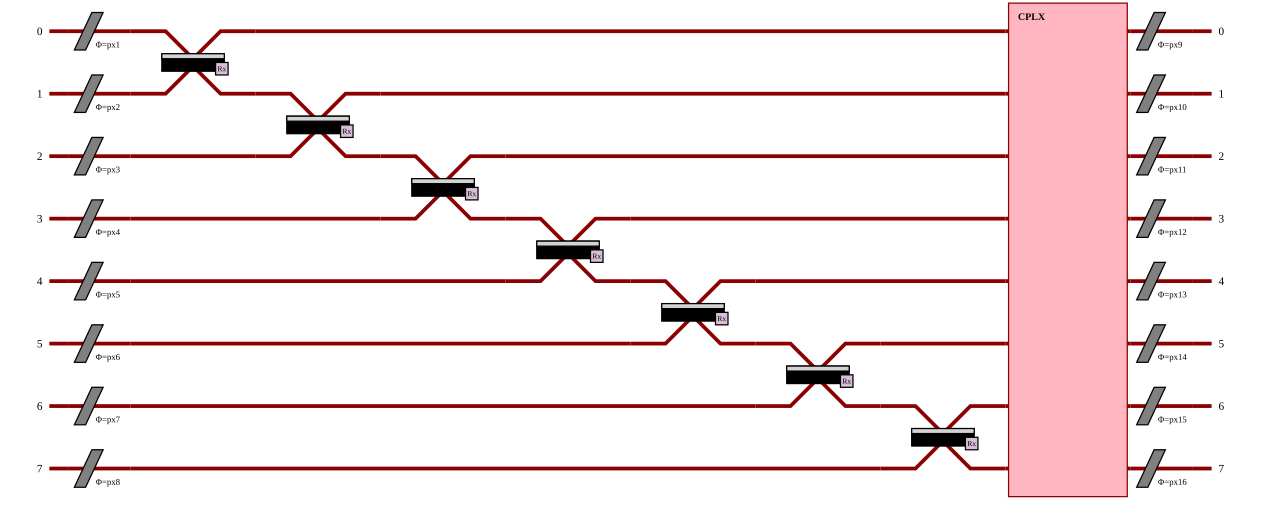

In [ ]:
qrc = PhotonicQuantumReservoirNetwork(
    n_modes   = N_MODES,
    n_photons = N_PHOTONS,
    epsilon_q = LEAKY_EPS,
    tikh_q    = LAMBDA_BASE,
    dim       = N_PCA,
    config    = 2
)

qlayer = qrc.qlayer
q_dim  = qrc.N_units

print("Quantum reservoir units (Fock-space dim):", q_dim)

# Inspect the perceval circuit
pcvl_circuit = qlayer.circuit
print("Circuit object:", pcvl_circuit)
pcvl.pdisplay(pcvl_circuit)

##  Step 9 — Leaky QRC Forward Pass (Reservoir States)

We run the photonic echo-state network over all timesteps.

- A **warmup** phase of `WARMUP` steps lets the reservoir synchronise with the input.
- `MEMORY_R` feedback dimensions are appended from the previous reservoir state to give the circuit temporal memory.
- The resulting matrices `Z_train` and `Z_test` are the rich Fock-space feature representations.

In [ ]:
@torch.no_grad()
def run_qrc(X_np):
    z_prev = torch.zeros(q_dim)
    Z_all  = []

    for t in range(len(X_np)):
        u        = torch.tensor(X_np[t], dtype=torch.float32)
        feedback = z_prev[:MEMORY_R]

        u_concat = torch.cat([u, feedback]).unsqueeze(0)
        phi      = qlayer(u_concat).squeeze(0)

        z_new  = (1 - LEAKY_EPS) * z_prev + LEAKY_EPS * phi
        z_prev = z_new

        Z_all.append(z_new.numpy())

    Z = np.array(Z_all)
    return Z[WARMUP:]   # rmup


print("Generating quantum reservoir features...")
Z_train = run_qrc(X_train)
Z_test  = run_qrc(X_test)

Y_train_eff = Y_train[WARMUP:]   # post-warmup states

print("Z_train shape:", Z_train.shape)
print("Z_test  shape:", Z_test.shape)
print("Y_train_eff shape:", Y_train_eff.shape)

Generating quantum reservoir features...
Z_train shape: (370, 330)
Z_test  shape: (78, 330)
Y_train_eff shape: (370, 16)


##  Step 10 — Lyapunov-Based Adaptive Regularisation

Instead of a fixed λ, we estimate the maximum singular value of the reservoir's increments `ΔZ` as a proxy for the system's dynamic gain.

If `σ_max > 1`, the reservoir is amplifying perturbations and needs stronger regularisation — λ is scaled accordingly.

In [ ]:
dZ       = Z_train[1:] - Z_train[:-1]
sigma_max = np.linalg.svd(dZ, compute_uv=False)[0]

lambda_adaptive = LAMBDA_BASE * max(1.0, sigma_max)

print("Estimated dynamic gain (σ_max):", sigma_max)
print("Adaptive lambda:               ", lambda_adaptive)

# Singular value spectrum
sv = np.linalg.svd(dZ, compute_uv=False)
plt.figure(figsize=(8, 4))
plt.semilogy(sv, linewidth=2)
plt.title("Singular Value Spectrum of ΔZ (Reservoir Dynamics)")
plt.xlabel("Index")
plt.ylabel("Singular Value (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

##  Step 11 — Ridge Readout Training

We fit a linear readout `W` from reservoir states → PCA increments.

Closed-form solution: `W = (Z_aug^T Z_aug + λI)^{-1} Z_aug^T Y`

A bias column is appended to `Z` before solving.

In [ ]:
def fit_ridge(Z, Y, lam):
    Z_aug = np.hstack([Z, np.ones((len(Z), 1))])
    A     = Z_aug.T @ Z_aug + lam * np.eye(Z_aug.shape[1])
    B     = Z_aug.T @ Y
    return np.linalg.solve(A, B)


def predict(W, Z):
    Z_aug = np.hstack([Z, np.ones((len(Z), 1))])
    return Z_aug @ W


W = fit_ridge(Z_train, Y_train_eff, lambda_adaptive)
print("Readout weight shape:", W.shape)

Readout weight shape: (331, 16)


##  Step 12 — Evaluation: PCA-Space Metrics

We predict the next-step PCA increments on the test set and compare against ground truth.

In [ ]:
dY_pred = predict(W, Z_test)

# Reconstruct next-step PCA levels: X_{t+1} = X_t + ΔX_pred
Y_pred  = X_test[-len(dY_pred):] + dY_pred
Y_true  = Y[split:][-len(dY_pred):]

# PCA-space MSE per component
pca_mse  = np.mean((Y_pred - Y_true)**2, axis=0)
pca_rmse = np.sqrt(pca_mse)
rel_rmse = pca_rmse / np.std(Y_true, axis=0)

print("\nPCA Component MSE:")
for i, mse in enumerate(pca_mse):
    print(f"  PC{i:02d}: {mse:.6f}")

print("\nPCA Relative RMSE (%):")
for i, rel in enumerate(rel_rmse):
    print(f"  PC{i:02d}: {rel*100:.2f}%")

# Bar chart of per-component RMSE
plt.figure(figsize=(10, 4))
plt.bar(range(N_PCA), rel_rmse * 100, color='steelblue')
plt.xlabel("PCA Component")
plt.ylabel("Relative RMSE (%)")
plt.title("Per-Component Relative RMSE in PCA Space")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##  Step 13 — Surface Reconstruction & Global Metrics

We invert PCA and MinMax scaling to reconstruct the full volatility surfaces in original units, then compute surface-level MAE, MSE, RMSE and R².

In [ ]:
surf_pred = scaler.inverse_transform(pca.inverse_transform(Y_pred))
surf_true = scaler.inverse_transform(pca.inverse_transform(Y_true))

y_true_flat = surf_true.flatten()
y_pred_flat = surf_pred.flatten()

MAE  = mean_absolute_error(y_true_flat, y_pred_flat)
MSE  = mean_squared_error(y_true_flat, y_pred_flat)
RMSE = np.sqrt(MSE)
R2   = r2_score(y_true_flat, y_pred_flat)

print("\n===== SURFACE METRICS =====")
print(f"MAE  : {MAE:.8f}")
print(f"MSE  : {MSE:.8f}")
print(f"RMSE : {RMSE:.8f}")
print(f"R²   : {R2:.6f}")


===== SURFACE METRICS =====
MAE  : 0.00246496
MSE  : 0.00001104
RMSE : 0.00332191
R²   : 0.998809


## Step 14 — Error Distribution

In [ ]:
error_surface = surf_pred - surf_true

plt.figure(figsize=(8, 5))
sns.histplot(error_surface.flatten(), bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Surface Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##  15 — Visual Surface Comparison (Flat heatmaps)

Quick flat-row heatmaps for a few test days — True | Predicted | Absolute Error.

In [ ]:
days_to_plot = [0, 10, 20]

for day in days_to_plot:
    true_surface      = surf_true[day]
    pred_surface      = surf_pred[day]
    abs_error_surface = np.abs(true_surface - pred_surface)

    vmin = min(true_surface.min(), pred_surface.min())
    vmax = max(true_surface.max(), pred_surface.max())

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    im1 = plt.imshow(true_surface.reshape(1, -1), aspect="auto", vmin=vmin, vmax=vmax, cmap="viridis")
    plt.title(f"True Surface — Day {day}")
    plt.colorbar(im1)

    plt.subplot(1, 3, 2)
    im2 = plt.imshow(pred_surface.reshape(1, -1), aspect="auto", vmin=vmin, vmax=vmax, cmap="viridis")
    plt.title(f"Predicted Surface — Day {day}")
    plt.colorbar(im2)

    plt.subplot(1, 3, 3)
    im3 = plt.imshow(abs_error_surface.reshape(1, -1), aspect="auto", vmin=0, vmax=abs_error_surface.max(), cmap="inferno")
    plt.title(f"Absolute Error — Day {day}")
    plt.colorbar(im3)

    plt.tight_layout()
    plt.show()

## — 2D Contour Plots on Tenor × Maturity Grid

We reshape the flat surface vectors back onto the proper Tenor × Maturity grid and plot contours.

In [ ]:
day_idx = min(20, len(surf_true) - 1)

true_grid  = reshape_surface(surf_true[day_idx])
pred_grid  = reshape_surface(surf_pred[day_idx])
error_grid = np.abs(true_grid - pred_grid)

vmin = min(true_grid.min(), pred_grid.min())
vmax = max(true_grid.max(), pred_grid.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c1 = axes[0].contourf(unique_tenors, unique_maturities, true_grid.T,
                      levels=30, vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title(f"True Surface — Day {day_idx}")
axes[0].set_xlabel("Tenor"); axes[0].set_ylabel("Maturity")
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(unique_tenors, unique_maturities, pred_grid.T,
                      levels=30, vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title(f"Predicted Surface — Day {day_idx}")
axes[1].set_xlabel("Tenor"); axes[1].set_ylabel("Maturity")
fig.colorbar(c2, ax=axes[1])

c3 = axes[2].contourf(unique_tenors, unique_maturities, error_grid.T,
                      levels=30, cmap="inferno")
axes[2].set_title(f"Absolute Error — Day {day_idx}")
axes[2].set_xlabel("Tenor"); axes[2].set_ylabel("Maturity")
fig.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.show()

##  — Multi-Step Forecast (6 Steps Ahead)

Starting from the last known PCA level, we autoregressively forecast 6 steps into the future using the trained reservoir + ridge readout.

In [ ]:
def forecast_next_steps(last_factor, steps=6):
    """Autoregressive multi-step forecast in PCA space."""
    forecasts      = []
    z_prev         = torch.zeros(q_dim)
    current_factor = last_factor.copy()

    for _ in range(steps):
        u        = torch.tensor(current_factor, dtype=torch.float32)
        feedback = z_prev[:MEMORY_R]

        u_concat = torch.cat([u, feedback]).unsqueeze(0)

        with torch.no_grad():
            phi = qlayer(u_concat).squeeze(0)

        z_new  = (1 - LEAKY_EPS) * z_prev + LEAKY_EPS * phi
        z_prev = z_new

        z_np    = z_new.cpu().numpy()
        z_aug   = np.append(z_np, 1.0)
        delta   = z_aug @ W

        current_factor = current_factor + delta
        forecasts.append(current_factor.copy())

    return np.array(forecasts)


last_factor        = factors[-1].copy()
future_pca_levels  = forecast_next_steps(last_factor, steps=6)

print("Future PCA shape:", future_pca_levels.shape)

future_surfaces = scaler.inverse_transform(
    pca.inverse_transform(future_pca_levels)
)
print("Future surface shape:", future_surfaces.shape)

Future PCA shape: (6, 16)
Future surface shape: (6, 224)


## Step 18 — Plot Forecast Vol Surfaces

In [ ]:
for i in range(6):
    surface = reshape_surface(future_surfaces[i])

    plt.figure(figsize=(7, 5))
    c = plt.contourf(unique_tenors, unique_maturities, surface.T, levels=30, cmap="viridis")
    plt.title(f"Forecast Vol Surface — Step t+{i+1}")
    plt.xlabel("Tenor")
    plt.ylabel("Maturity")
    plt.colorbar(c, label="Implied Vol")
    plt.tight_layout()
    plt.show()

##  — Save Forecast to CSV

In [ ]:
future_df = pd.DataFrame(future_surfaces, columns=surface_cols)
future_df.insert(0, "Forecast_Step", [f"t+{i+1}" for i in range(6)])

output_path = "future_6_step_vol_forecast_level2.csv"
future_df.to_csv(output_path, index=False)

print(f"Forecast CSV saved as: {output_path}")
future_df.head()

Forecast CSV saved as: future_6_step_vol_forecast_level2.csv


,Forecast_Step,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,t+1,0.023520,0.031653,0.033661,0.035305,0.035867,0.035323,0.034973,0.034673,0.034960,...,0.343894,0.342041,0.344290,0.337967,0.339506,0.336430,0.359540,0.374848,0.355046,0.344793
1,t+2,0.023507,0.031639,0.033650,0.035295,0.035861,0.035319,0.034971,0.034672,0.034960,...,0.343816,0.341963,0.344215,0.337892,0.339435,0.336365,0.359466,0.374767,0.354974,0.344730
2,t+3,0.023494,0.031626,0.033638,0.035286,0.035855,0.035314,0.034969,0.034671,0.034959,...,0.343738,0.341885,0.344139,0.337817,0.339365,0.336299,0.359391,0.374687,0.354902,0.344667
3,t+4,0.023480,0.031612,0.033627,0.035277,0.035849,0.035310,0.034966,0.034669,0.034958,...,0.343660,0.341806,0.344063,0.337742,0.339294,0.336234,0.359316,0.374606,0.354829,0.344604
4,t+5,0.023467,0.031599,0.033615,0.035268,0.035843,0.035305,0.034964,0.034668,0.034957,...,0.343581,0.341728,0.343986,0.337667,0.339223,0.336169,0.359241,0.374525,0.354757,0.344542


# References


- H. Jaeger,
``The echo state approach to analysing and training recurrent neural networks,''
GMD Report 148, 2001.


- M. Lukoševičius and H. Jaeger,
``Reservoir computing approaches to recurrent neural network training,''
Computer Science Review, 2009.

- E. Ott,
\textit{Chaos in Dynamical Systems},
Cambridge University Press, 2002.


- D. Verstraeten et al.,
``An experimental unification of reservoir computing methods,''
Neural Networks, 2007.